In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import scipy.io as sio
from PIL import Image
import numpy as np

In [47]:
# --------------------- 数据集 ---------------------
class MultiModalDataset(Dataset):
    def __init__(self, image_paths, nir_data, labels, transform=None):
        self.image_paths = image_paths
        self.nir_data = nir_data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx][0]  # 这里是路径
        img = Image.open(img_path).convert('RGB')  # 正确打开图片！

        if self.transform:
            img = self.transform(img)  # 对PIL Image应用transform
        
        nir = torch.tensor(self.nir_data[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return img, nir, label

In [48]:
# --------------------- 图像特征提取器（金字塔） ---------------------
class PyramidCNN(nn.Module):
    def __init__(self):
        super(PyramidCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x.view(x.size(0), -1)

# --------------------- NIR特征提取器（A-CNN + A-GRU） ---------------------
class NIRAttentionExtractor(nn.Module):
    def __init__(self):
        super(NIRAttentionExtractor, self).__init__()
        # A-CNN: 卷积 + 通道注意力（SE block）
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.se_block = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid()
        )
        # A-GRU: GRU + Attention
        self.gru = nn.GRU(input_size=128, hidden_size=64, batch_first=True, bidirectional=True)
        self.attn_fc = nn.Linear(128, 1)

    def forward(self, x):
        # x shape: (batch_size, 128)
        # A-CNN
        x_cnn = x.unsqueeze(1)  # (batch_size, 1, 128)
        x_cnn = self.conv(x_cnn)  # (batch_size, 64, 128)
        se = self.se_block(x_cnn).unsqueeze(-1)  # (batch_size, 64, 1)
        x_cnn = x_cnn * se  # SE加权
        x_cnn = torch.mean(x_cnn, dim=-1)  # (batch_size, 64)

        # A-GRU
        x_gru = x.unsqueeze(1)  # (batch_size, 1, 128)
        x_gru, _ = self.gru(x_gru)  # (batch_size, 1, 128)
        attn_weights = torch.softmax(self.attn_fc(x_gru).squeeze(-1), dim=-1).unsqueeze(-1)  # (batch_size, 1, 1)
        x_gru = torch.sum(x_gru * attn_weights, dim=1)  # (batch_size, 128)

        # 融合局部+序列特征
        features = torch.cat([x_cnn, x_gru], dim=1)  # (batch_size, 64+128=192)
        return features

# --------------------- 蒸馏三分类模型 ---------------------
class MultiModalNet(nn.Module):
    def __init__(self):
        super(MultiModalNet, self).__init__()
        self.image_encoder = PyramidCNN()
        self.nir_encoder = NIRAttentionExtractor()
        self.fc = nn.Sequential(
            nn.Linear(128 + 192, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, img, nir):
        img_feat = self.image_encoder(img)
        nir_feat = self.nir_encoder(nir)
        fused = torch.cat([img_feat, nir_feat], dim=1)
        out = self.fc(fused)
        return out

Epoch 1: Val Acc = 0.2667
Best model updated at epoch 1
Epoch 2: Val Acc = 0.2667
Epoch 3: Val Acc = 0.4222
Best model updated at epoch 3
Epoch 4: Val Acc = 0.4222
Epoch 5: Val Acc = 0.4222
Epoch 6: Val Acc = 0.4222
Epoch 7: Val Acc = 0.4222
Epoch 8: Val Acc = 0.4222
Epoch 9: Val Acc = 0.4222
Epoch 10: Val Acc = 0.4889
Best model updated at epoch 10
Epoch 11: Val Acc = 0.5222
Best model updated at epoch 11
Epoch 12: Val Acc = 0.5222
Epoch 13: Val Acc = 0.5222
Epoch 14: Val Acc = 0.5222
Epoch 15: Val Acc = 0.5444
Best model updated at epoch 15
Epoch 16: Val Acc = 0.4000
Epoch 17: Val Acc = 0.4444
Epoch 18: Val Acc = 0.4444
Epoch 19: Val Acc = 0.4444
Epoch 20: Val Acc = 0.4333
Epoch 21: Val Acc = 0.4444
Epoch 22: Val Acc = 0.4444
Epoch 23: Val Acc = 0.4444
Epoch 24: Val Acc = 0.4333
Epoch 25: Val Acc = 0.4889
Epoch 26: Val Acc = 0.4667
Epoch 27: Val Acc = 0.4778
Epoch 28: Val Acc = 0.5000
Epoch 29: Val Acc = 0.5778
Best model updated at epoch 29
Epoch 30: Val Acc = 0.6000
Best model upda

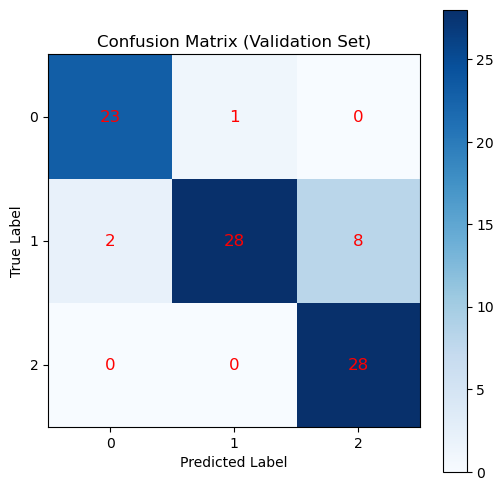

C:\Users\enine\AppData\Local\Temp\ipykernel_392\2267943284.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Best Model Test Accuracy: 0.8111111111111111


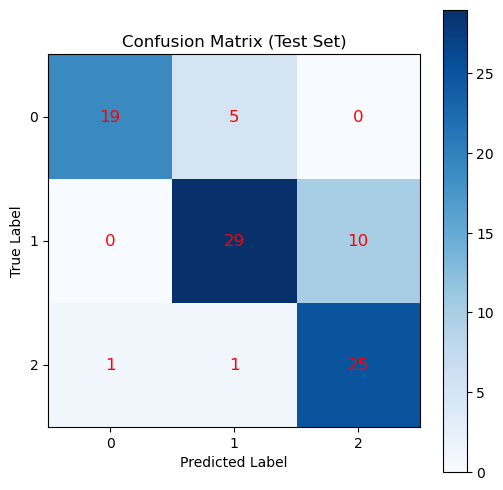

In [ ]:
# --------------------- 主程序 ---------------------
# 加载数据
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 训练集的数据增强
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

# 验证集和测试集，只做基本处理
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
image_dataset = ImageFolder(root=r"L:\\常惠林\\萎凋\\所有样本", transform=transform)
nir_mat = sio.loadmat(r"L:\\常惠林\\萎凋\\NIR.mat")
nir_data = nir_mat['nir']  # (300, 128)

# 数据划分
# 划分训练集（40%）和临时集（60%）
train_idx, temp_idx = train_test_split(
    range(300),
    test_size=0.6,  # 留60%给验证+测试
    stratify=image_dataset.targets,  # 分层抽样，保持类别比例
    random_state=42
)

# 划分验证集（20%）和测试集（40%）
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,  
    stratify=[image_dataset.targets[i] for i in temp_idx],  # 保持类别比例一致
    random_state=42
)

def subset(dataset, idxs):
    imgs = [dataset.imgs[i] for i in idxs]
    targets = [dataset.targets[i] for i in idxs]
    return imgs, targets

train_imgs, train_labels = subset(image_dataset, train_idx)
val_imgs, val_labels = subset(image_dataset, val_idx)
test_imgs, test_labels = subset(image_dataset, test_idx)

# 注意，分别赋不同的transform！
train_dataset = MultiModalDataset(train_imgs, nir_data[train_idx], train_labels, transform=train_transform)
val_dataset = MultiModalDataset(val_imgs, nir_data[val_idx], val_labels, transform=val_test_transform)
test_dataset = MultiModalDataset(test_imgs, nir_data[test_idx], test_labels, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=48, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=48)
test_loader = DataLoader(test_dataset, batch_size=48)

# 初始化模型
model = MultiModalNet().cuda()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


# ------------------ 训练 ------------------
best_acc = 0
for epoch in range(200):
    model.train()
    for imgs, nirs, labels in train_loader:
        imgs, nirs, labels = imgs.cuda(), nirs.cuda(), labels.cuda()
        optimizer.zero_grad()
        outputs = model(imgs, nirs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # 每轮结束后验证
    model.eval()
    preds_val, trues_val = [], []
    with torch.no_grad():
        for imgs, nirs, labels in val_loader:
            imgs, nirs = imgs.cuda(), nirs.cuda()
            outputs = model(imgs, nirs)
            preds_val.extend(outputs.argmax(dim=1).cpu().numpy())
            trues_val.extend(labels.numpy())

    acc = accuracy_score(trues_val, preds_val)
    print(f"Epoch {epoch+1}: Val Acc = {acc:.4f}")

    # 保存验证集上效果最好的模型及其在验证集的预测
    if acc > best_acc:
        best_acc = acc
        best_val_preds = preds_val.copy()
        best_val_trues = trues_val.copy()
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best model updated at epoch {epoch+1}")

# ------------------ 验证集混淆矩阵（best model） ------------------
cm_val = confusion_matrix(best_val_trues, best_val_preds)
val_acc = accuracy_score(best_val_trues, best_val_preds)

print("Best Model Validation Accuracy:", val_acc)

plt.figure(figsize=(6, 6))
plt.imshow(cm_val, cmap='Blues')
plt.title('Confusion Matrix (Validation Set)')
plt.colorbar()

classes = np.arange(cm_val.shape[0])

for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        plt.text(j, i, str(cm_val[i, j]), ha='center', va='center', color='red', fontsize=12)

plt.xticks(classes)
plt.yticks(classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ------------------ 测试集混淆矩阵（best model） ------------------
# 加载最佳模型
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds_test, trues_test = [], []
with torch.no_grad():
    for imgs, nirs, labels in test_loader:
        imgs, nirs = imgs.cuda(), nirs.cuda()
        outputs = model(imgs, nirs)
        preds_test.extend(outputs.argmax(dim=1).cpu().numpy())
        trues_test.extend(labels.numpy())

cm_test = confusion_matrix(trues_test, preds_test)
test_acc = accuracy_score(trues_test, preds_test)

print("Best Model Test Accuracy:", test_acc)

plt.figure(figsize=(6, 6))
plt.imshow(cm_test, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()

classes = np.arange(cm_test.shape[0])

for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, str(cm_test[i, j]), ha='center', va='center', color='red', fontsize=12)

plt.xticks(classes)
plt.yticks(classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()